# **Problem 2 (100 points)**

This problem is about the basics of neural network.

Before starting this problem, make sure to run the following code first **without change**:

In [ ]:
""" DO NOT CHANGE """
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(2025)

$\color{red}{\text{WARNING !!!}}$

* Beyond importing libraries/modules/classes/functions in the preceeding cell, you are **NOT allowed to import anything else for the following purposes**:

    * **As a part of your final solution.** For instance, if a problem asks you to build a model without using sklearn but you use it, then you will not earn points.

    * **Temporarily import something to assist you to get a solution.** For instance, if a problem asks you to manually compute eigenvalues but you temporarily use `np.linalg.eig` to get an answer and then delete your code, then you violate the rule.

  **Rule of thumb:** Each part has its particular purpose to intentionally test you something. Do not attempt to find a shortcut to circumvent the rule.

* All coding tasks shall run on CPUs, **not GPUs**.

## **Part 1 (5 points, non-coding task)**

The high level idea of affine transformation in math is that for each column vector $\mathbf{x} \in \Bbb R^N$, an affine transformation maps it to another column vector $\mathbf{y} \in \Bbb R^M$ via

$$
\mathbf{y} = \mathbf{W} \mathbf{x} + \mathbf{b} ,
$$

where

* $\mathbf{W} \in \Bbb R^{M \times N}$.

* $\mathbf{b} \in \Bbb R^{M}$.

Now, let us study a small-sized problem.

Let

$$
\mathbf{W}
= \begin{bmatrix}
2 & -3 & 1 & 3 & -2 \\
0 & 1 & 2 & 5 & -1 \\
7 & -1 & -3 & 7 & 0
\end{bmatrix}
$$

and

$$
\mathbf{b}
= \begin{bmatrix}
1 \\
0 \\
-1
\end{bmatrix}
$$

and

$$
\mathbf{x}
= \begin{bmatrix}
1 \\
2 \\
-3 \\
1 \\
-2
\end{bmatrix}
$$

**Answer the following questions:**

1. What is the value of $N$?

2. What is the value of $M$?

3. What is the value of $\mathbf{y}$.

Questions 1 and 2 do not require reasoning. Question 3 requires reasoning.

$\color{green}{\text{### WRITE YOUR SOLUTION HERE ###}}$

1. $N = 5$.

2. $M = 3$.

3. We have

\begin{align*} \mathbf{y} & = \mathbf{W} \mathbf{x} + \mathbf{b} \\ & = \begin{bmatrix} 2 & -3 & 1 & 3 & -2 \\ 0 & 1 & 2 & 5 & -1 \\ 7 & -1 & -3 & 7 & 0 \end{bmatrix} \begin{bmatrix} 1 \\ 2 \\ -3 \\ 1 \\ -2 \end{bmatrix} + \begin{bmatrix} 1 \\ 0 \\ -1 \end{bmatrix} \\ & = \begin{bmatrix} 2 \cdot 1 + (-3) \cdot 2 + 1 \cdot (-3) | 3 \cdot 1 + (-2) \cdot (-2) + 1 \\ 0 \cdot 1 + 1 \cdot 2 + 2 \cdot (-3) + 5 \cdot 1 + (-1) \cdot (-2) + 0 \\ 7 \cdot 1 (-1) \cdot 2 + (-3) \cdot (-3) + 7 \cdot 1 + 0 \cdot (-2) + (-1) \end{bmatrix} \\ & = \boxed{\begin{bmatrix} 1 \\ 3 \\ 20 \end{bmatrix} }. \end{align*}

$\color{red}{\text{""" END OF THIS PART """}}$





## **Part 2 (10 points, non-coding task)**

Define $\nabla_{\mathbf{z}} \ f\left( \mathbf{z} \right)$ to be the gradient of function $f$ with respect to vector/matrix $\mathbf{z}$.

**Compute the following gradients. Reasoning is required.**

1. $\nabla_{\mathbf{x}} \ y$.

   The final answer should be in a matrix form.

2. $\nabla_{\mathbf{W}} \ y$.

   The final answer should be in an element-wise form.

3. $\nabla_{\mathbf{b}} \ y$.

   The final answer should be in a matrix form.

$\color{green}{\text{### WRITE YOUR SOLUTION HERE ###}}$

1. Since $\mathbf{y} \in \Bbb R^M$ and $\mathbf{x} \in \Bbb R^N$, $\nabla_{\mathbf{x}} \ \mathbf{y} \in \Bbb R^{M \times N}$.
We have

\begin{align*} \frac{\partial y_m}{\partial x_n} & = \frac{\partial \left( \sum_{i=0}^{N-1} w_{mi} x_i + b_m \right)}{\partial x_n} \\ & = w_{mn} . \end{align*}
Therefore,

$$\boxed{\nabla_{\mathbf{x}} \ \mathbf{y} = \mathbf{W} }.$$

2. Since $\mathbf{y} \in \Bbb R^M$ and $\mathbf{W} \in \Bbb R^{M \times N}$, $\nabla_{\mathbf{W}} \ \mathbf{y} \in \Bbb R^{M \times M \times N}$.
We have

$$\begin{align*} \frac{\partial y_m}{\partial w_{kn}} & = \frac{\partial \left( \sum_{i=0}^{N-1} w_{mi} x_i + b_m \right)}{\partial w_{kn}} \\ & = \boxed{x_n \delta_{mk}}. \end{align*}$$

3. Since $\mathbf{y} \in \Bbb R^M$ and $\mathbf{b} \in \Bbb R^M$, $\nabla_{\mathbf{b}} \ \mathbf{y} \in \Bbb R^{M \times M}$.
We have

$$\begin{align*} \frac{\partial y_m}{\partial w_k} & = \frac{\partial \left( \sum_{i=0}^{N-1} w_{mi} x_i + b_m \right)}{\partial b_k} \\ & = \delta_{mk} . \end{align*}$$
Therefore,

$$\boxed{\nabla_{\mathbf{b}} \ \mathbf{y} = \mathbf{I}_{M \times M}}$$ .

$\color{red}{\text{""" END OF THIS PART """}}$



## **Part 3 (10 points, coding task)**

In this part, you are asked to build an affine transformation module from scratch by using **NumPy, NOT PyTorch or TensorFlow**.

**Define such a class as `My_Linear_NumPy`.**

* Attributes

    * `in_features`: Number of input features

    * `out_features`: Number of output features
    
    * `weight`: This refers to matrix $\mathbf{W}$ in Part 1. The shape is `(out_features, in_features)`.

    * `bias`: This refers to vector $\mathbf{b}$ in Part 1. The shape is `(out_features,)`.

    * `random_seed`: The NumPy random seed number used to generate initial values of `weight` and `bias`.

* Method `__init__`:

    * To initialize an object in this class, you need to specify `in_features` and `out_features`.

    * You may initialize the object by specifying a value for `random_seed`. If it is not specified, then its default value is 42.

    * The initial values of `weight` and `bias` are random that follow standard normal distributions generated with the seed number attribute`random_seed`.

* Method `forward`: $ $

    * Input `x`: numpy array with shape `(n_0, n_1, ..., n_{d-1}, in_features)` with an arbitrary dimension $d = 0, 1, \cdots$.

    * Output `y`: numpy array with shape `(n_0, n_1, ..., n_{d-1}, out_features)`.

    * The affine transformation works in a way that given the first d indices in `x` and `y`, it does affine transformation along the last axis of `x` and `y`.

* **Do not use any loop in your code.**

In [ ]:
### WRITE YOUR SOLUTION HERE ###

class My_Linear_NumPy:
    def __init__(self, in_features, out_features, random_seed=42):
        self.in_features = in_features
        self.out_features = out_features
        self.random_seed = random_seed
        np.random.seed(self.random_seed)
        self.weight = np.random.randn(self.out_features, self.in_features)
        self.bias = np.random.randn(self.out_features)

    def forward(self, x):
        return np.sum(x[..., np.newaxis] * self.weight.T, axis = -2) + self.bias

""" END OF THIS PART """

' END OF THIS PART '

## **Part 4 (5 points, coding task)**

**Do the following tasks in this part.**

1. Construct an object in the class `My_Linear_Numpy` called `linear_model_np`.

2. Set `in_features = 3` and `out_features = 5`.

3. Create multiple `X` with the following different shapes, but common numpy random seed number 2025 and the same standard normal distribution.

    * `(in_features,)`

    * `(10,in_features)`

    * `(10,20,in_features)`

    * `(10,20,30,in_features)`

   After generating `X`, reset the numpy random seed number to its default value.

4. We call our constructed function with each of the above `X` as the input. Print the shape of each output.

In [ ]:
### WRITE YOUR SOLUTION HERE ###

in_features = 3
out_features = 5

linear_model_np = My_Linear_NumPy(in_features, out_features)

np.random.seed(2025)

X_list = [np.random.randn(in_features), np.random.randn(10,in_features), np.random.randn(10,20,in_features), np.random.randn(10,20,30,in_features)]

np.random.seed()

for X in X_list:
    print(linear_model_np.forward(X).shape)

""" END OF THIS PART """

(5,)
(10, 5)
(10, 20, 5)
(10, 20, 30, 5)


' END OF THIS PART '

# **Part 5 (10 points, coding task)**

In this part, you are asked to program with **PyTorch, NOT NumPy**.

**Define a deep neural network module (class) named `Linear_Model`.**

It has the following architecture:

* 2 layers: 1 hidden layer and 1 output layer.

* No activitation function. That is, the connection between two consecutive layers is only an affine transformation.

In [ ]:
### WRITE YOUR SOLUTION HERE ###

class Linear_Model(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.hidden_features = hidden_features
        self.out_features = out_features
        self.linear0 = nn.Linear(in_features, hidden_features)
        self.linear1 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.linear0(x)
        x = self.linear1(x)
        return x

""" END OF THIS PART """

' END OF THIS PART '

## **Part 6 (5 points, non-coding task)**

We make the following modifications on the previous part.

* We consider a special symmetric neural network that `out_features = in_features`.

* No bias in all affine transformations.

* The transformation matrix from the hidden layer to the output layer is binded to be the transpose of the transformation matrix from the input layer to the hidden layer

**What is the total number of learnable parameters in this model?**

* Reasoning is not required.

$\color{green}{\text{### WRITE YOUR SOLUTION HERE ###}}$

`in_features * hidden_features`

$\color{red}{\text{""" END OF THIS PART """}}$



## **Part 7 (5 points, non-coding task)**

This question follows Part 6.

Denote by $\mathbf{W} \in \Bbb R^{hidden\_features \times input\_features}$ the transformation matrix from the input layer to the hidden layer.

**Given input $\mathbf{x} \in \Bbb R^{input\_features}$, write down the formula of the output $\mathbf{y}$ and its shape.**

* Reasoning is not required.

$\color{green}{\text{### WRITE YOUR SOLUTION HERE ###}}$

$$\begin{align*} \mathbf{y} & = \mathbf{W}^\top \mathbf{W} \mathbf{x} \\ & \in \Bbb R^{input\_features} . \end{align*}$$

$\color{red}{\text{""" END OF THIS PART """}}$




## **Part 8 (10 points, non-coding task)**

This question follows Part 7.

Denote $r = \text{rank} \left( \mathbf{W} \right)$.

**Compute the rank of $\mathbf{W}^\top \mathbf{W}$.**

* Reasoning is required.



$\color{green}{\text{### WRITE YOUR SOLUTION HERE ###}}$

Let $\mathbf{W}$ be with the following singular value decomposition:

$$\mathbf{W} = \sum_{i = 0}^{r-1} \mathbf{u}_i \sigma_i \mathbf{v}_i^\top .$$

Hence,

\begin{align*} \mathbf{W}^\top \mathbf{W} & = \left( \sum_{i = 0}^{r-1} \mathbf{u}_i \sigma_i \mathbf{v}_i^\top \right)^\top \left( \sum_{j = 0}^{r-1} \mathbf{u}_j \sigma_j \mathbf{v}_j^\top \right) \\ & = \sum_{i = 0}^{r-1} \sum_{j = 0}^{r-1} \mathbf{v}_i \sigma_i \mathbf{u}_i^\top \mathbf{u}_j \sigma_j \mathbf{v}_j ^\top \\ & = \sum_{i = 0}^{r-1} \sum_{j = 0}^{r-1} \mathbf{v}_i \sigma_i \sigma_j \delta_{ij} \mathbf{v}_j^\top \\ & = \sum_{i = 0}^{r-1} \mathbf{v}_i \sigma_i^2 \mathbf{v}_j^\top . \end{align*}
This is the singular value decomposition of $\mathbf{W} \mathbf{W}^\top$. Therefore, the rank of this matrix is also $r$.

$\color{red}{\text{""" END OF THIS PART """}}$



## **Part 9 (5 points, coding task)**

This question follows Part 6.

In this part, you are asked to program with **PyTorch, not NumPy**.

**Build a deep neural network class named as `Symmetric_Linear_Model` that meets the modifications imposed in Part 6.**

In [ ]:
### WRITE YOUR SOLUTION HERE ###

class Symmetric_Linear_Model(nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        self.in_features = in_features
        self.hidden_features = hidden_features
        self.linear0 = nn.Linear(in_features, hidden_features, bias = False)

    def forward(self, x):
        x = self.linear0(x)
        x = torch.sum(self.linear0.weight * x.reshape(*x.shape, 1), dim = -2)
        return x


""" END OF THIS PART """

' END OF THIS PART '

## **Part 10 (5 points, coding task)**

Rectified Linear Unit, or the "ReLU", is one of the most common used function in deep learning. It is defined as

$$
\text{ReLU}(x)= \max \left\{ 0,x \right\} .
$$

**In this part, you are asked to use PyTorch to build a ReLU class named `My_ReLU` that subclasses `nn.module`.**

A successful class works in the following ways:

* The initialization of an object in `My_ReLU` does not take any input.

* Suppose we have a `My_ReLU` object called `activiation0`. When we call `activiation0(x)`with input `x` that is a tensor `x` with an arbitrary dimension and shape, we get an output `y` from the element-wise ReLU acvitivation on `x`.

In [ ]:
### WRITE YOUR SOLUTION HERE ###

class My_ReLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.max(torch.zeros_like(x), x)

""" END OF THIS PART """

' END OF THIS PART '

## **Part 11 (10 points, coding task)**

It is known by math that the combination of several linear layers can still be seen as an linear layer, so we can add some non-linear activation functions, such as ReLU, in between to get better effect.

Multi-Layer Perceptron (MLP), is such a neural network composed of multiple fully connected layers with non-linear activations, commonly used in deep learning.

**Please define a class called `My_MLP_Model` that subclasses `nn.Module` and works in the following ways:**

* The architecture consists of two hidden layers and one output layer.

* Each hidden layer consists of an affine transformation module and a ReLU activiation module.

* Each affine transformation module shall be initialized with the build-in class `nn.Linear`.

* Each ReLU activiatio nmodule shall be initialized with your self-defined class `My_ReLU`.

In [ ]:
### WRITE YOUR SOLUTION HERE ###

class My_MLP_Model(nn.Module):
    def __init__(self, in_features, hidden_features1, hidden_features2, out_features):
        super().__init__()
        self.in_features = in_features
        self.hidden_features1 = hidden_features1
        self.hidden_features2 = hidden_features2
        self.out_features = out_features
        self.seq = nn.Sequential(
            nn.Linear(in_features, hidden_features1),
            My_ReLU(),
            nn.Linear(hidden_features1, hidden_features2),
            My_ReLU(),
            nn.Linear(hidden_features2, out_features)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

""" END OF THIS PART """

' END OF THIS PART '

## **Part 12 (5 points, coding task)**

After building our deep neural network architecture in Part 11 and before using it to train our model, we need to prepare our training dataset.

Let us look at a simple application of deep neural network in studying harmonic motion in physics.

**Write code to construct the following training dataset:**

* Use `sample_size` to store the number of samples. Set the value as 1000.

* Define `x_train` as a tensor whose shape is `(sample_size,)` and the value on each entry is uniformly drawn between 0 and 1.

* Define `y_train` as a tensor whose values are obtained from the following element-wise mapping from `x_train`:

   $$
   y = \sin \left( 2 \pi x \right) + 0.1 \cdot \mathcal N \left( 0, 1 \right) ,
   $$

   where $\mathcal N \left( 0, 1 \right)$ is a standard normal random variable.

* Print the dimensions of `x_train` and `y_train`.

* Print the shapes of `x_train` and `y_train`.

In [ ]:
### WRITE YOUR SOLUTION HERE ###

sample_size = 1000
x_train = torch.rand(sample_size,)
y_train = torch.sin(2 * np.pi * x_train) + 0.1 * torch.randn_like(x_train)

print(x_train.ndim)
print(y_train.ndim)

print(x_train.shape)
print(y_train.shape)

""" END OF THIS PART """

1
1
torch.Size([1000])
torch.Size([1000])


' END OF THIS PART '

## **Part 13 (15 points, coding task)**

**In this part, we use the training dataset constructed in Part 12 to train a model defined in Part 11.**

* Use mean-squred error (MSE) as the loss function.

* Use Adam as the optimization algorithm.

* Do whole-batch training in each epoch.

* After every 10 epochs, print the following sentence:

   Epoch: XXX. Loss: XXX.
   
   The loss value should be with 4 decimal places.

* Generate an epoch-MSE loss plot after completing the training. Set the x-label as `epoch` and the y-label as `MSE loss`.

In [ ]:
# HYPERPARAMETERS
''' DO NOT CHANGE ANYTHING IN THIS CODE CELL '''

hidden_features1 = 32
hidden_features2 = 16

num_epochs = 500
learning_rate = 1e-3

Epoch: 0. Loss: 0.7823
Epoch: 10. Loss: 0.6733
Epoch: 20. Loss: 0.5941
Epoch: 30. Loss: 0.5393
Epoch: 40. Loss: 0.4971
Epoch: 50. Loss: 0.4652
Epoch: 60. Loss: 0.4402
Epoch: 70. Loss: 0.4155
Epoch: 80. Loss: 0.3894
Epoch: 90. Loss: 0.3615
Epoch: 100. Loss: 0.3314
Epoch: 110. Loss: 0.2997
Epoch: 120. Loss: 0.2678
Epoch: 130. Loss: 0.2371
Epoch: 140. Loss: 0.2095
Epoch: 150. Loss: 0.1864
Epoch: 160. Loss: 0.1682
Epoch: 170. Loss: 0.1548
Epoch: 180. Loss: 0.1451
Epoch: 190. Loss: 0.1382
Epoch: 200. Loss: 0.1329
Epoch: 210. Loss: 0.1284
Epoch: 220. Loss: 0.1245
Epoch: 230. Loss: 0.1208
Epoch: 240. Loss: 0.1173
Epoch: 250. Loss: 0.1140
Epoch: 260. Loss: 0.1107
Epoch: 270. Loss: 0.1075
Epoch: 280. Loss: 0.1044
Epoch: 290. Loss: 0.1014
Epoch: 300. Loss: 0.0984
Epoch: 310. Loss: 0.0956
Epoch: 320. Loss: 0.0928
Epoch: 330. Loss: 0.0901
Epoch: 340. Loss: 0.0875
Epoch: 350. Loss: 0.0850
Epoch: 360. Loss: 0.0825
Epoch: 370. Loss: 0.0802
Epoch: 380. Loss: 0.0779
Epoch: 390. Loss: 0.0758
Epoch: 400.

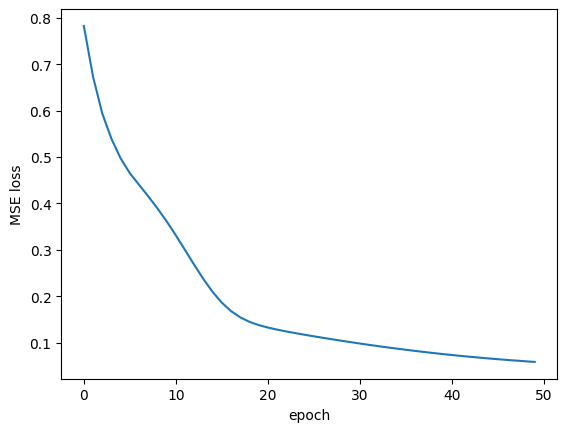

' END OF THIS PART '

In [ ]:
### WRITE YOUR SOLUTION HERE ###

my_mlp_model = My_MLP_Model(1, hidden_features1, hidden_features2, 1)
optimizer = torch.optim.Adam(my_mlp_model.parameters(), lr = learning_rate)
loss_fn = torch.nn.MSELoss()

loss_list_plot = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = my_mlp_model(x_train.reshape(-1,1))
    loss = loss_fn(y_pred, y_train.reshape(-1,1))
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}. Loss: {loss.item():.4f}")
        loss_list_plot.append(loss.item())

plt.plot(loss_list_plot)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()
""" END OF THIS PART """

**END OF THIS PROBLEM**